<a href="https://colab.research.google.com/github/nikhilasaipreeti/AI_CO_PO/blob/main/pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving CSE_Employability_Dataset.xlsx to CSE_Employability_Dataset.xlsx


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_excel("CSE_Employability_Dataset.xlsx")

df.head()

,StudentID,Name,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,...,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining,Employability
0,1,Tejas,20,Male,8.01,8,9,5,6,3,...,7,5,2,9,4,No,3,1,Yes,High
1,2,Vegeta,21,Female,7.27,10,7,4,4,7,...,9,8,7,3,5,No,4,2,Yes,High
2,3,Reiner,23,Female,8.27,8,9,9,5,4,...,6,7,1,6,3,No,1,3,Yes,High
3,4,Brook,24,Female,9.20,10,10,2,4,6,...,8,3,9,1,8,Yes,8,3,No,High
4,5,Harsha,20,Male,8.74,10,10,10,8,3,...,4,3,10,6,4,Yes,4,3,No,Medium


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(100, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          100 non-null    int64  
 1   Name               100 non-null    object 
 2   Age                100 non-null    int64  
 3   Gender             100 non-null    object 
 4   CGPA               100 non-null    float64
 5   Programming        100 non-null    int64  
 6   DSA                100 non-null    int64  
 7   DBMS               100 non-null    int64  
 8   OS                 100 non-null    int64  
 9   CN                 100 non-null    int64  
 10  Python             100 non-null    int64  
 11  Java               100 non-null    int64  
 12  WebDevelopment     100 non-null    int64  
 13  AI_ML              100 non-null    int64  
 14  Cloud              100 non-null    int64  
 15  DevOps             100 non-null    int64  
 16  CyberSecurity    

In [5]:
print(df.isnull().sum())

StudentID            0
Name                 0
Age                  0
Gender               0
CGPA                 0
Programming          0
DSA                  0
DBMS                 0
OS                   0
CN                   0
Python               0
Java                 0
WebDevelopment       0
AI_ML                0
Cloud                0
DevOps               0
CyberSecurity        0
Communication        0
Aptitude             0
Teamwork             0
Internship           0
Certifications       0
Projects             0
PlacementTraining    0
Employability        0
dtype: int64


In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

imputer = SimpleImputer(strategy='mean')

df[num_cols] = imputer.fit_transform(df[num_cols])

In [8]:
print(df.isnull().sum())

StudentID            0
Name                 0
Age                  0
Gender               0
CGPA                 0
Programming          0
DSA                  0
DBMS                 0
OS                   0
CN                   0
Python               0
Java                 0
WebDevelopment       0
AI_ML                0
Cloud                0
DevOps               0
CyberSecurity        0
Communication        0
Aptitude             0
Teamwork             0
Internship           0
Certifications       0
Projects             0
PlacementTraining    0
Employability        0
dtype: int64


In [9]:
print(df.select_dtypes(include='object').columns)

Index(['Name', 'Gender', 'Internship', 'PlacementTraining', 'Employability'], dtype='object')


In [12]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df["Internship"] = encoder.fit_transform(df["Internship"])

df["PlacementTraining"] = encoder.fit_transform(df["PlacementTraining"])

df["Employability"] = encoder.fit_transform(df["Employability"])

In [11]:
df = df.drop(["StudentID","Name"], axis=1)

df.head()

,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,Python,Java,...,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining,Employability
0,20.0,1,8.01,8.0,9.0,5.0,6.0,3.0,9.0,3.0,...,7.0,5.0,2.0,9.0,4.0,0,3.0,1.0,1,0
1,21.0,0,7.27,10.0,7.0,4.0,4.0,7.0,1.0,2.0,...,9.0,8.0,7.0,3.0,5.0,0,4.0,2.0,1,0
2,23.0,0,8.27,8.0,9.0,9.0,5.0,4.0,8.0,5.0,...,6.0,7.0,1.0,6.0,3.0,0,1.0,3.0,1,0
3,24.0,0,9.20,10.0,10.0,2.0,4.0,6.0,7.0,1.0,...,8.0,3.0,9.0,1.0,8.0,1,8.0,3.0,0,0
4,20.0,1,8.74,10.0,10.0,10.0,8.0,3.0,10.0,5.0,...,4.0,3.0,10.0,6.0,4.0,1,4.0,3.0,0,2


In [15]:
# Features
X = df.drop("Employability", axis=1)

# Target
y = df["Employability"]

print(X.head())
print(y.head())

    Age  Gender  CGPA  Programming   DSA  DBMS   OS   CN  Python  Java  ...  \
0  20.0       1  8.01          8.0   9.0   5.0  6.0  3.0     9.0   3.0  ...   
1  21.0       0  7.27         10.0   7.0   4.0  4.0  7.0     1.0   2.0  ...   
2  23.0       0  8.27          8.0   9.0   9.0  5.0  4.0     8.0   5.0  ...   
3  24.0       0  9.20         10.0  10.0   2.0  4.0  6.0     7.0   1.0  ...   
4  20.0       1  8.74         10.0  10.0  10.0  8.0  3.0    10.0   5.0  ...   

   Cloud  DevOps  CyberSecurity  Communication  Aptitude  Teamwork  \
0    2.0     7.0            5.0            2.0       9.0       4.0   
1    9.0     9.0            8.0            7.0       3.0       5.0   
2    8.0     6.0            7.0            1.0       6.0       3.0   
3    8.0     8.0            3.0            9.0       1.0       8.0   
4    3.0     4.0            3.0           10.0       6.0       4.0   

   Internship  Certifications  Projects  PlacementTraining  
0           0             3.0       1.0    

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Age,Gender,CGPA,Programming,DSA,DBMS,OS,CN,Python,Java,...,Cloud,DevOps,CyberSecurity,Communication,Aptitude,Teamwork,Internship,Certifications,Projects,PlacementTraining
0,-1.250837,0.960769,0.249195,-0.433809,0.247100,-0.127867,0.209615,-1.021237,1.139659,-0.830205,...,-1.072489,0.637921,-0.044347,-1.216473,1.189663,-0.479132,-1.0,-0.368484,-1.610685,0.886405
1,-0.559767,-1.040833,-0.355607,1.115508,-1.347095,-0.473454,-0.455829,0.453473,-1.674314,-1.184993,...,1.388961,1.320189,0.979055,0.501709,-0.809771,-0.131935,-1.0,0.032042,-1.014135,0.886405
2,0.822373,-1.040833,0.461693,-0.433809,0.247100,1.254479,-0.123107,-0.652559,0.787912,-0.120628,...,1.037325,0.296787,0.637921,-1.560110,0.189946,-0.826329,-1.0,-1.169535,-0.417585,0.886405
3,1.513443,-1.040833,1.221782,1.115508,1.044198,-1.164627,-0.455829,0.084796,0.436166,-1.539782,...,1.037325,0.979055,-0.726616,1.188982,-1.476248,0.909656,1.0,1.634145,-0.417585,-1.128152
4,-1.250837,0.960769,0.845824,1.115508,1.044198,1.600066,0.875059,-1.021237,1.491405,-0.120628,...,-0.720853,-0.385481,-0.726616,1.532619,0.189946,-0.479132,1.0,0.032042,-0.417585,-1.128152


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (80, 22)
Testing Data : (20, 22)


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

X_pipeline = pipeline.fit_transform(X)

print("Pipeline Applied Successfully")

Pipeline Applied Successfully


In [19]:
processed = pd.DataFrame(X_pipeline, columns=X.columns)

processed["Employability"] = y

processed.to_excel("Processed_CSE_Employability_Dataset.xlsx", index=False)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


In [20]:
from google.colab import files

files.download("Processed_CSE_Employability_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
print(X.describe())

              Age      Gender        CGPA  Programming         DSA  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    21.810000    0.520000    7.705100     8.560000    8.690000   
std      1.454321    0.502117    1.229704     1.297394    1.260872   
min     20.000000    0.000000    5.570000     5.000000    5.000000   
25%     20.750000    0.000000    6.570000     8.000000    8.000000   
50%     22.000000    1.000000    7.785000     9.000000    9.000000   
75%     23.000000    1.000000    8.680000    10.000000   10.000000   
max     24.000000    1.000000    9.750000    10.000000   10.000000   

             DBMS          OS          CN      Python        Java  ...  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  ...   
mean     5.370000    5.370000    5.770000    5.760000    5.340000  ...   
std      2.908209    3.020653    2.726062    2.857278    2.832781  ...   
min      1.000000    1.000000    1.000000    1.000000    1.000000  ...   

In [22]:
print(processed.describe())

                Age        Gender          CGPA   Programming           DSA  \
count  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02   
mean   8.393286e-16  2.664535e-17  8.371082e-16 -4.207745e-16  4.554690e-16   
std    1.005038e+00  1.005038e+00  1.005038e+00  1.005038e+00  1.005038e+00   
min   -1.250837e+00 -1.040833e+00 -1.745018e+00 -2.757785e+00 -2.941290e+00   
25%   -7.325342e-01 -1.040833e+00 -9.277177e-01 -4.338088e-01 -5.499973e-01   
50%    1.313033e-01  9.607689e-01  6.530230e-02  3.408498e-01  2.471002e-01   
75%    8.223733e-01  9.607689e-01  7.967861e-01  1.115508e+00  1.044198e+00   
max    1.513443e+00  9.607689e-01  1.671298e+00  1.115508e+00  1.044198e+00   

               DBMS            OS            CN        Python          Java  \
count  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02  1.000000e+02   
mean  -9.547918e-17 -2.997602e-17  1.398881e-16  5.551115e-17  6.217249e-17   
std    1.005038e+00  1.005038e+00  1.005038e+00  1.

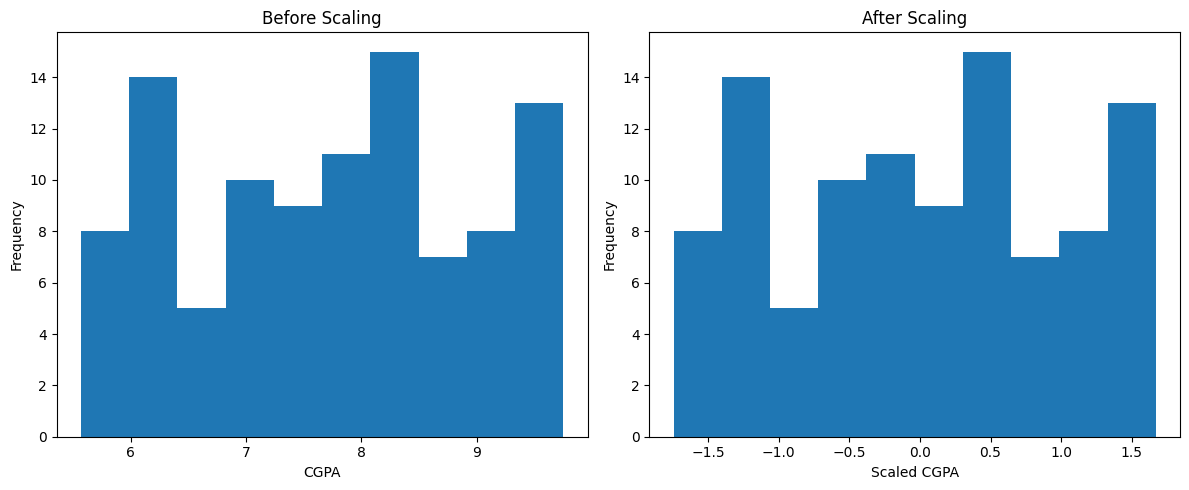

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Before Scaling
plt.subplot(1,2,1)
plt.hist(X["CGPA"], bins=10)
plt.title("Before Scaling")
plt.xlabel("CGPA")
plt.ylabel("Frequency")

# After Scaling
plt.subplot(1,2,2)
plt.hist(processed["CGPA"], bins=10)
plt.title("After Scaling")
plt.xlabel("Scaled CGPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()